# Gradient Descent with Momentum

Plain gradient descent treats each step as independent — it has no memory of past gradients. On ill-conditioned landscapes this causes oscillations that slow convergence dramatically. **Momentum** fixes this by adding a velocity term, turning GD into a discretized **damped harmonic oscillator** — the same second-order ODE from the Unit 4 mass-spring notebook.

## Motivation: The Problem with Plain GD

On the function $f(x,y) = x^2 + 10y^2$ (condition number $\kappa = 10$), gradient descent zigzags:

- The gradient in the $y$-direction is large relative to $x$, so each step overcorrects in $y$.
- With a learning rate safe for $y$, progress along $x$ is painfully slow.
- This is a consequence of having no memory: each step ignores which direction has been consistently wrong.

The fix: accumulate a **velocity** vector that smooths out oscillating gradients while amplifying consistent ones.

## The Heavy Ball ODE

*(Recall from Unit 4: the mass-spring-damper system is $m\ddot{x} + c\dot{x} + kx = 0$, a second-order ODE rewritten as a first-order system by introducing velocity $v = \dot{x}$.)*

Consider adding inertia to gradient flow. Instead of $\dot{x} = -\nabla f(x)$ (first-order, no memory), we write the **heavy ball ODE**:

$$\boxed{\ddot{x} = -\nabla f(x) - \gamma\,\dot{x}}$$

Interpreting: the "particle" $x(t)$ has inertia, experiences a gradient restoring force $-\nabla f(x)$ (like a spring), and is damped by $\gamma\dot{x}$ (like a dashpot).

| Mass-spring | Heavy ball optimization |
|---|---|
| Spring constant $k$ | Curvature of $f$ (Hessian eigenvalue) |
| Damping coefficient $c$ | Friction $\gamma$ |
| Position $x(t)$ | Parameter iterate |
| Restoring force $-kx$ | Gradient force $-\nabla f(x)$ |

- **$\gamma = 0$** (no damping): the particle oscillates forever, never converging.
- **$\gamma > 0$** (damped): the particle oscillates with decreasing amplitude, settling at a minimum.
- **$\gamma$ large** (overdamped): recovers first-order gradient flow — no oscillation, but slow.

### Discretization

Introduce the velocity variable $v = \dot{x}$ and apply forward Euler to the first-order system:

$$v_{k+1} = v_k + \eta(-\nabla f(x_k) - \gamma v_k) = (1 - \eta\gamma)v_k - \eta\,\nabla f(x_k)$$

Setting $\beta = 1 - \eta\gamma$ (the **momentum coefficient**) and writing $v_{k+1}$ before updating $x_k$:

$$\boxed{v_{k+1} = \beta\,v_k - \eta\,\nabla f(x_k)}, \qquad \boxed{x_{k+1} = x_k + v_{k+1}}$$

When $\beta = 0$, this collapses to plain GD ($v_{k+1} = -\eta\,\nabla f(x_k)$, $x_{k+1} = x_k - \eta\,\nabla f(x_k)$).

## Parameter Roles

| Parameter | Role | Typical value |
|---|---|---|
| $\eta$ | Learning rate — Euler step size | $0.001$ – $0.1$ |
| $\beta$ | Momentum coefficient — fraction of previous velocity retained | $0.9$ (common default) |
| $\beta = 0$ | Recovers plain gradient descent | — |
| $\beta \to 1$ | Underdamped — fast but oscillates | — |
| $\beta \approx 0.9$ | Well-damped, fast convergence | — |

The effective step incorporates an exponentially-weighted average of past gradients: $v_k \approx -\eta\sum_{j \leq k} \beta^{k-j}\nabla f(x_j)$, with contributions from step $j$ decaying at rate $\beta^{k-j}$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('dark_background')
np.random.seed(42)


def gradient_descent(grad_f, x0, eta, n_steps, tol=1e-9):
    """Plain GD: x_{k+1} = x_k - eta * grad_f(x_k)."""
    x = np.asarray(x0, dtype=float)
    history = [x.copy()]
    for _ in range(n_steps):
        g = np.asarray(grad_f(x), dtype=float)
        if np.linalg.norm(g) < tol:
            break
        x = x - eta * g
        history.append(x.copy())
    return history


def gd_momentum(grad_f, x0, eta, beta, n_steps, tol=1e-9):
    """
    GD with momentum: v_{k+1} = beta*v_k - eta*grad_f(x_k),  x_{k+1} = x_k + v_{k+1}.

    Parameters
    ----------
    grad_f  : callable(x) -> ndarray
    x0      : array-like, starting point
    eta     : float, learning rate
    beta    : float, momentum coefficient in [0, 1)
    n_steps : int, maximum iterations
    tol     : float, stop when ||grad_f|| < tol

    Returns
    -------
    history : list of np.ndarray iterates
    """
    x = np.asarray(x0, dtype=float)
    v = np.zeros_like(x)
    history = [x.copy()]
    for _ in range(n_steps):
        g = np.asarray(grad_f(x), dtype=float)
        if np.linalg.norm(g) < tol:
            break
        v = beta * v - eta * g
        x = x + v
        history.append(x.copy())
    return history


## Toy 1D: Non-Convex Landscape

We compare plain GD vs GD+momentum on $f(x) = x^2 - 3\cos(10x)$ from the same starting point. The same learning rate $\eta = 0.02$ is used for both; momentum uses $\beta = 0.85$.

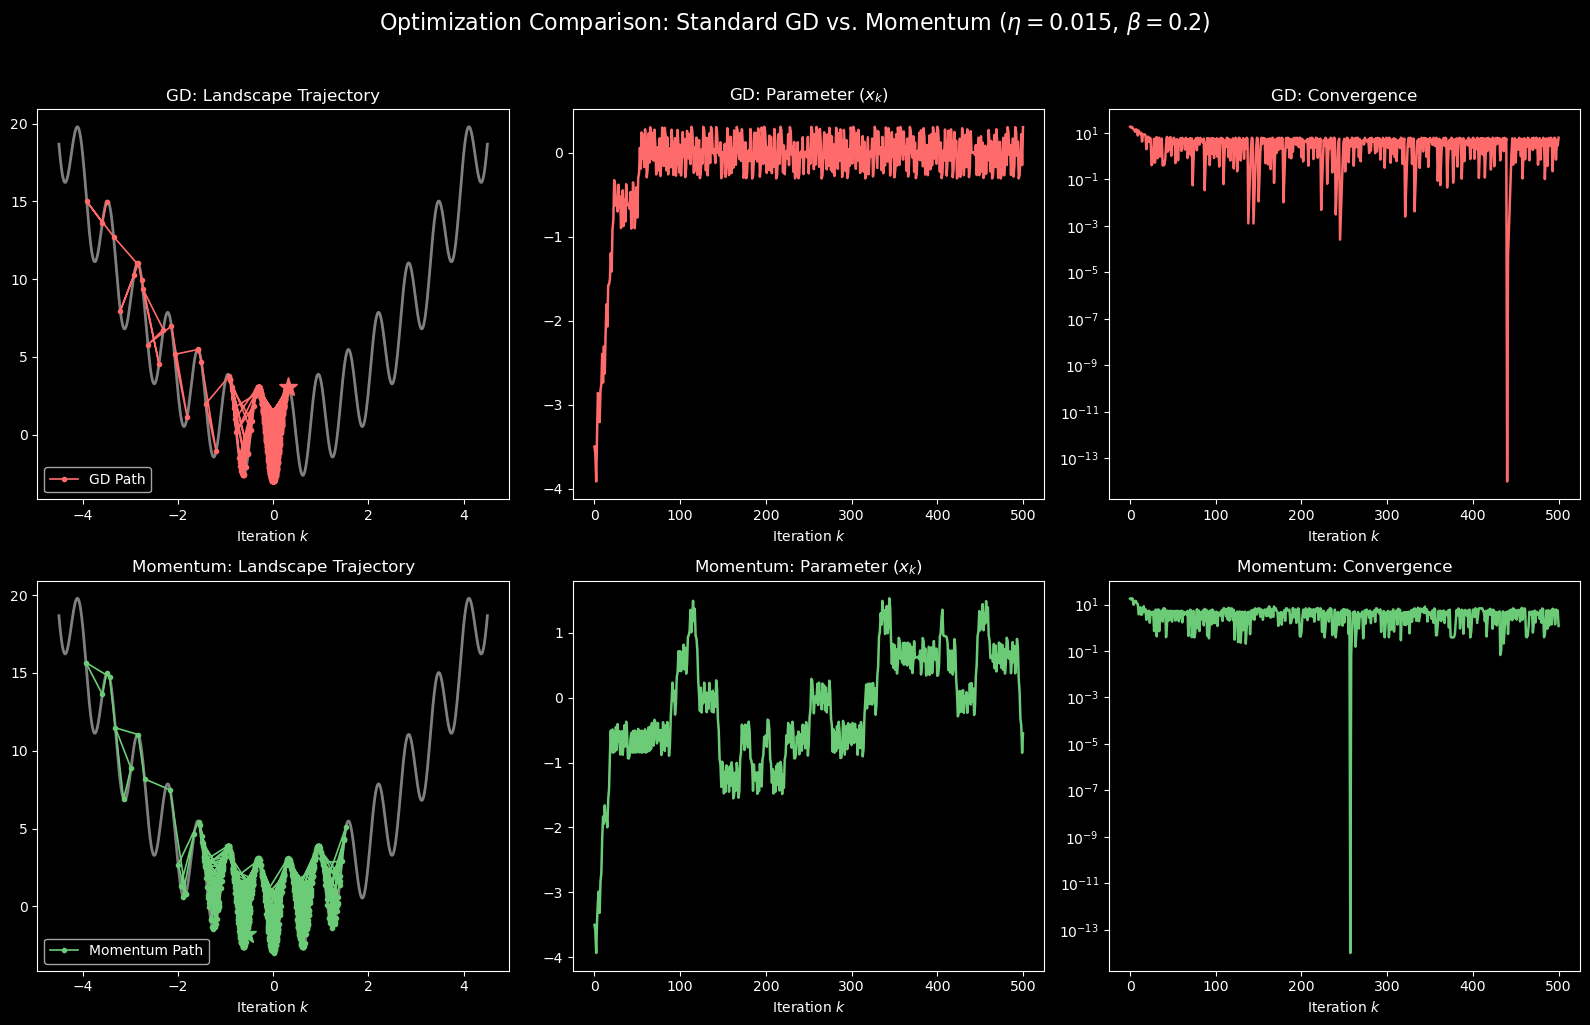

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Function and Gradients
f1d  = lambda x: x**2 - 3 * np.cos(10 * x)
df1d = lambda x: 2 * x + 30 * np.sin(10 * x)
grad1d = lambda x: np.array([df1d(x[0])])

# 2. Hyperparameters
x0_1d = np.array([-3.5])
eta_1d = 0.015
beta_1d = 0.2
n_iters = 500

# Assuming these functions are defined in your environment:
hist_gd  = gradient_descent(grad1d, x0_1d, eta_1d, n_iters)
hist_mom = gd_momentum(grad1d, x0_1d, eta_1d, beta_1d, n_iters)

xs_gd  = np.array([h[0] for h in hist_gd])
xs_mom = np.array([h[0] for h in hist_mom])
x_grid = np.linspace(-4.5, 4.5, 1000)

# 3. Plotting
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# --- ROW 1: STANDARD GRADIENT DESCENT ---
# Landscape
axes[0, 0].plot(x_grid, f1d(x_grid), 'w-', lw=2, alpha=0.5)
axes[0, 0].plot(xs_gd, f1d(xs_gd), 'o-', color='#FF6B6B', ms=3, lw=1.2, label='GD Path')
axes[0, 0].plot(xs_gd[-1], f1d(xs_gd[-1]), '*', color='#FF6B6B', ms=14)
axes[0, 0].set_title('GD: Landscape Trajectory', fontsize=12)
axes[0, 0].legend()

# Parameter Path
axes[0, 1].plot(xs_gd, '-', color='#FF6B6B', lw=1.8)
axes[0, 1].set_title('GD: Parameter ($x_k$)', fontsize=12)

# Convergence
ref_gd = f1d(xs_gd).min()
axes[0, 2].semilogy(np.abs(f1d(xs_gd) - ref_gd) + 1e-14, '-', color='#FF6B6B', lw=1.8)
axes[0, 2].set_title('GD: Convergence', fontsize=12)


# --- ROW 2: GD + MOMENTUM ---
# Landscape
axes[1, 0].plot(x_grid, f1d(x_grid), 'w-', lw=2, alpha=0.5)
axes[1, 0].plot(xs_mom, f1d(xs_mom), 'o-', color='#6BCB77', ms=3, lw=1.2, label='Momentum Path')
axes[1, 0].plot(xs_mom[-1], f1d(xs_mom[-1]), '*', color='#6BCB77', ms=14)
axes[1, 0].set_title('Momentum: Landscape Trajectory', fontsize=12)
axes[1, 0].legend()

# Parameter Path
axes[1, 1].plot(xs_mom, '-', color='#6BCB77', lw=1.8)
axes[1, 1].set_title('Momentum: Parameter ($x_k$)', fontsize=12)

# Convergence
ref_mom = f1d(xs_mom).min()
axes[1, 2].semilogy(np.abs(f1d(xs_mom) - ref_mom) + 1e-14, '-', color='#6BCB77', lw=1.8)
axes[1, 2].set_title('Momentum: Convergence', fontsize=12)

# Shared Labels
for ax in axes.flat:
    ax.set_xlabel('Iteration $k$')

plt.suptitle(
    fr'Optimization Comparison: Standard GD vs. Momentum ($\eta={eta_1d}$, $\beta={beta_1d}$)', 
    fontsize=16, y=1.02
)
plt.tight_layout()
plt.show()

## Toy 2D: Elongated Valley

On $f(x,y) = x^2 + 10y^2$ (the ill-conditioned function from the GD notebook), momentum transforms the zigzagging path into a smooth glide along the valley floor. The left panel shows both trajectories on the same contour plot; the right shows convergence speed.

<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:62: SyntaxWarning: invalid escape sequence '\l'
<>:46: SyntaxWarning: invalid escape sequence '\l'
<>:62: SyntaxWarning: invalid escape sequence '\l'
C:\Users\Graham West\AppData\Local\Temp\ipykernel_23984\197055678.py:46: SyntaxWarning: invalid escape sequence '\l'
  axes[0, 1].set_ylabel('$\log(f)$')
C:\Users\Graham West\AppData\Local\Temp\ipykernel_23984\197055678.py:62: SyntaxWarning: invalid escape sequence '\l'
  axes[1, 1].set_ylabel('$\log(f)$')


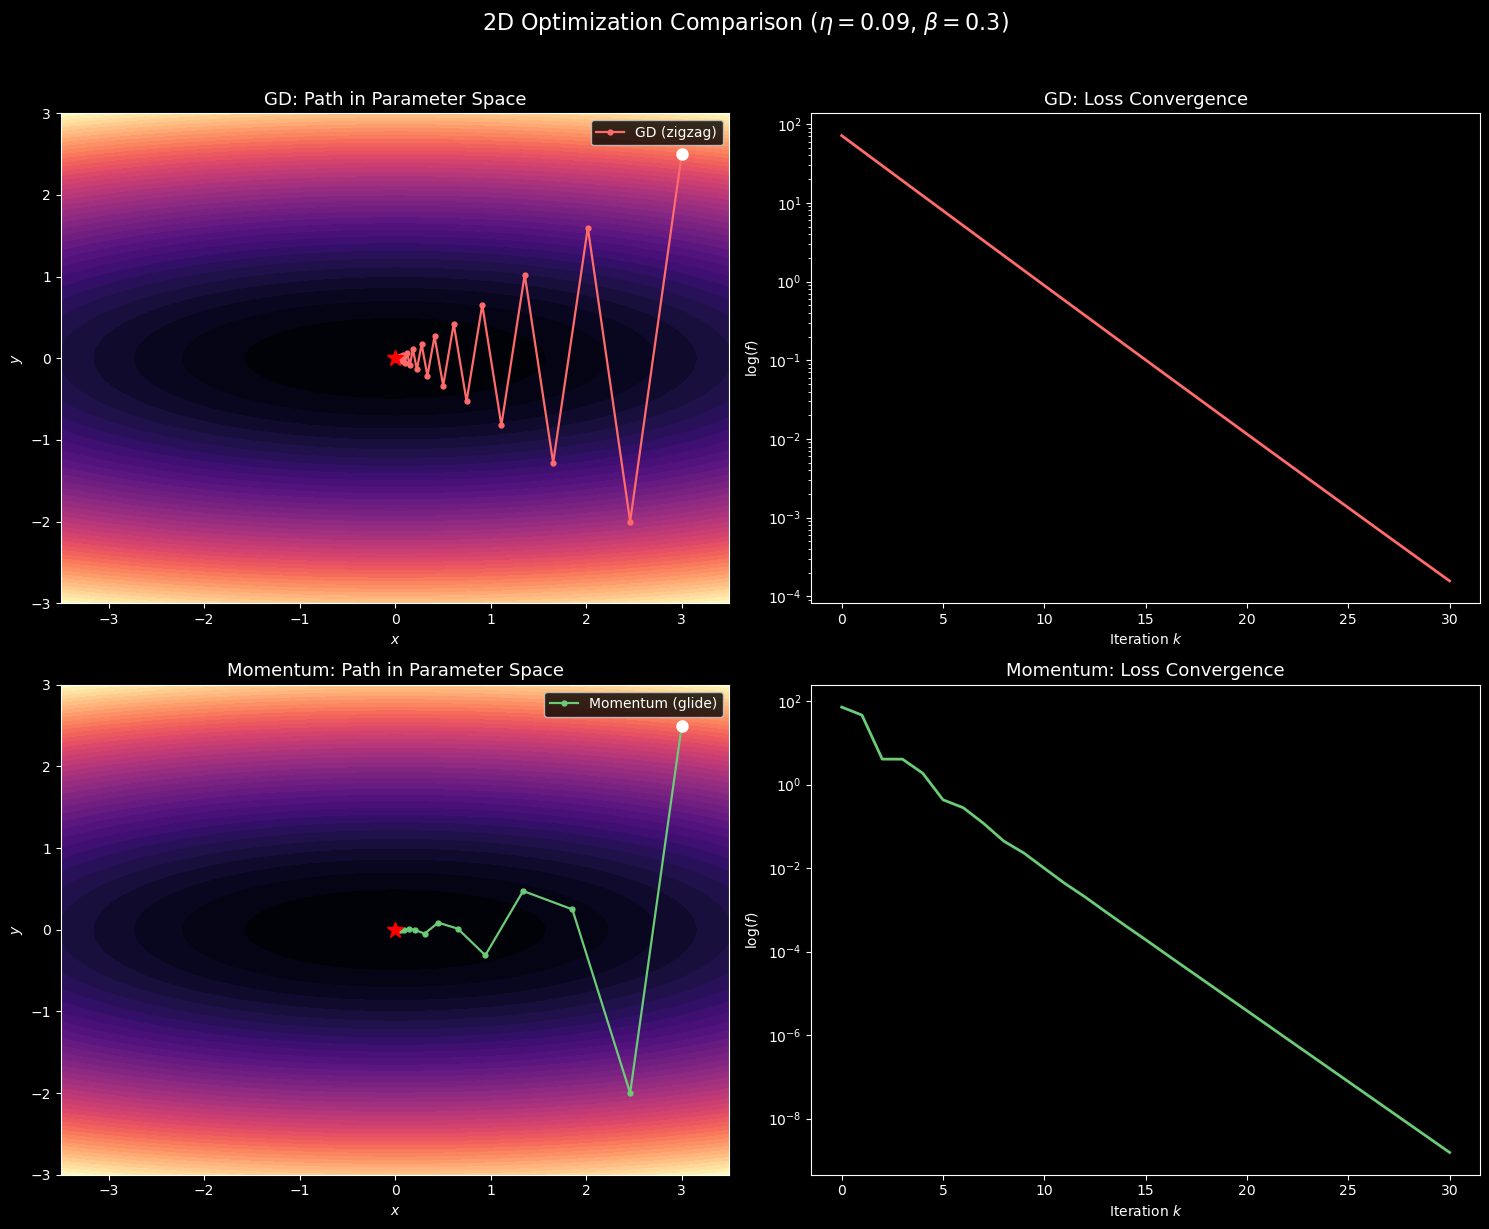

--- Metrics ---
Iterations to halve loss — GD: 2, Momentum: 2
Final Loss — GD: 0.000156, Momentum: 0.000000


In [33]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define Function and Gradients
def f2d_val(xy): 
    return xy[0]**2 + 10 * xy[1]**2

def grad_f2d(xy):
    return np.array([2 * xy[0], 20 * xy[1]])

# 2. Hyperparameters
x0_2d = np.array([3.0, 2.5])
eta_2d  = 0.09
beta_2d = 0.3
n_iters = 30

# Optimization runs
hist_gd2  = gradient_descent(grad_f2d, x0_2d, eta_2d, n_iters)
hist_mom2 = gd_momentum(grad_f2d, x0_2d, eta_2d, beta_2d, n_iters)

traj_gd2  = np.array(hist_gd2)
traj_mom2 = np.array(hist_mom2)

# 3. Create Grid for Contours
xv = np.linspace(-3.5, 3.5, 300)
yv = np.linspace(-3.0, 3.0, 300)
Xg, Yg = np.meshgrid(xv, yv)
Zg = Xg**2 + 10 * Yg**2

# 4. Plotting (2 Rows)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# --- ROW 1: STANDARD GRADIENT DESCENT ---
# Contour Path
cs1 = axes[0, 0].contourf(Xg, Yg, Zg, levels=40, cmap='magma')
axes[0, 0].plot(traj_gd2[:, 0], traj_gd2[:, 1], 'o-', color='#FF6B6B', ms=3.5, lw=1.6, label='GD (zigzag)')
axes[0, 0].plot(*x0_2d, 'wo', ms=8)
axes[0, 0].plot(0, 0, 'r*', ms=12)
axes[0, 0].set_title('GD: Path in Parameter Space', fontsize=13)
axes[0, 0].legend()

# Convergence
fv_gd2 = np.array([f2d_val(p) for p in hist_gd2])
axes[0, 1].semilogy(fv_gd2, '-', color='#FF6B6B', lw=2)
axes[0, 1].set_title('GD: Loss Convergence', fontsize=13)
axes[0, 1].set_ylabel('$\log(f)$')


# --- ROW 2: GD + MOMENTUM ---
# Contour Path
cs2 = axes[1, 0].contourf(Xg, Yg, Zg, levels=40, cmap='magma')
axes[1, 0].plot(traj_mom2[:, 0], traj_mom2[:, 1], 'o-', color='#6BCB77', ms=3.5, lw=1.6, label='Momentum (glide)')
axes[1, 0].plot(*x0_2d, 'wo', ms=8)
axes[1, 0].plot(0, 0, 'r*', ms=12)
axes[1, 0].set_title('Momentum: Path in Parameter Space', fontsize=13)
axes[1, 0].legend()

# Convergence
fv_mom2 = np.array([f2d_val(p) for p in hist_mom2])
axes[1, 1].semilogy(fv_mom2, '-', color='#6BCB77', lw=2)
axes[1, 1].set_title('Momentum: Loss Convergence', fontsize=13)
axes[1, 1].set_ylabel('$\log(f)$')

# Formatting
for ax in axes[:, 0]:
    ax.set_xlabel('$x$')
    ax.set_ylabel('$y$')
for ax in axes[:, 1]:
    ax.set_xlabel('Iteration $k$')

plt.suptitle(fr'2D Optimization Comparison ($\eta={eta_2d}$, $\beta={beta_2d}$)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# 5. Efficiency Metrics
k_half_gd  = next((k for k, v in enumerate(fv_gd2)  if v < fv_gd2[0] / 2), len(fv_gd2))
k_half_mom = next((k for k, v in enumerate(fv_mom2) if v < fv_mom2[0] / 2), len(fv_mom2))

print(f'--- Metrics ---')
print(f'Iterations to halve loss — GD: {k_half_gd}, Momentum: {k_half_mom}')
print(f'Final Loss — GD: {fv_gd2[-1]:.6f}, Momentum: {fv_mom2[-1]:.6f}')

## Application: Least Squares

We apply both methods to the same 1D linear and nonlinear regression problems from the GD notebook, comparing convergence speed.

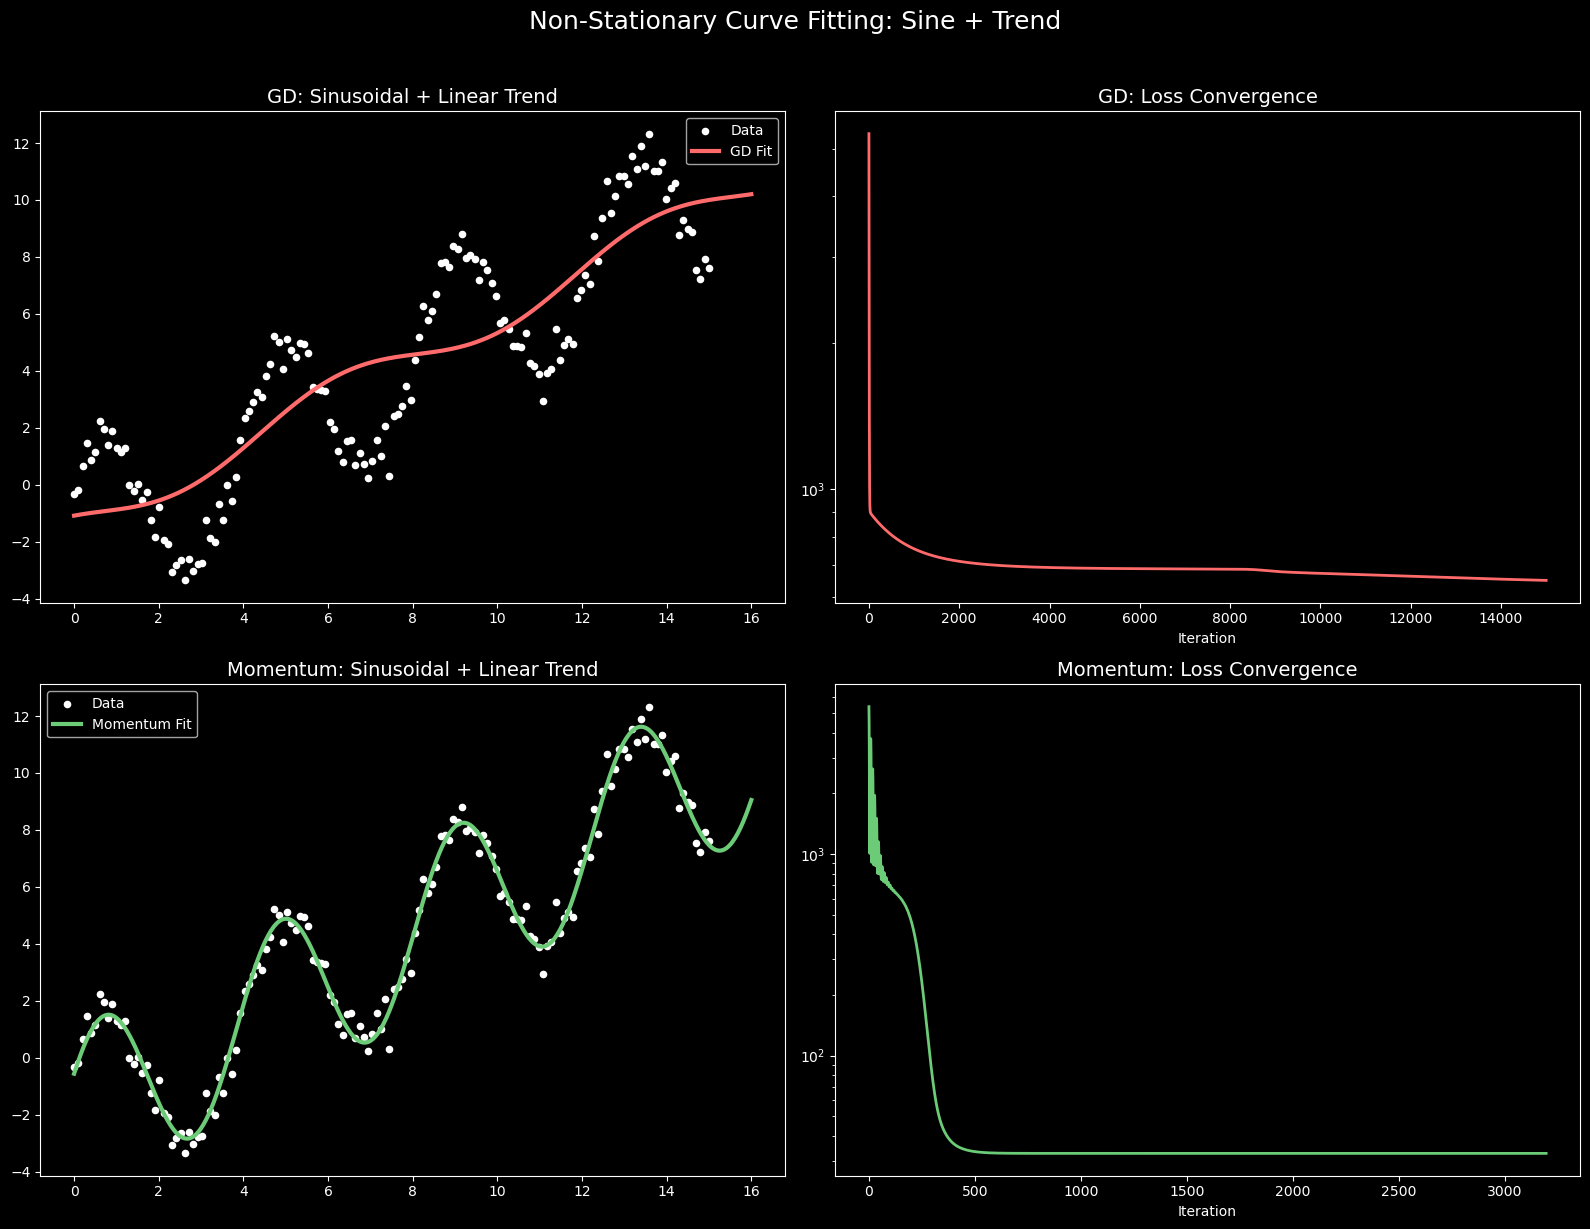

Param        | True     | GD       | Momentum
--------------------------------------------------
Amp (A)      | 3.00     | -0.66    | -2.97   
Freq (w)     | 1.50     | 0.85     | 1.50    
Phase (phi)  | 0.50     | -0.60    | -2.61   
Slope (m)    | 0.80     | 0.74     | 0.80    
Intercept (c) | -2.00    | -1.46    | -2.07   


In [32]:
# 1. Generate Synthetic Trend + Sine Data
np.random.seed(42)
N = 150
x_data = np.linspace(0, 15, N)

# True parameters: [Amplitude, Freq, Phase, Slope, Intercept]
p_true = np.array([3.0, 1.5, 0.5, 0.8, -2.0])

def trend_sine_model(x, p):
    A, w, phi, m, c = p
    return A * np.sin(w * x + phi) + (m * x + c)

y_data = trend_sine_model(x_data, p_true) + 0.5 * np.random.randn(N)

# 2. Define Loss and Gradient Functions
def loss_trend(p):
    return np.sum((y_data - trend_sine_model(x_data, p))**2)

def grad_trend(p):
    A, w, phi, m, c = p
    arg = w * x_data + phi
    sin_arg = np.sin(arg)
    cos_arg = np.cos(arg)
    
    resid = y_data - trend_sine_model(x_data, p)
    
    # Partial Derivatives
    dA = -2 * np.dot(sin_arg, resid)
    dw = -2 * np.dot(A * x_data * cos_arg, resid)
    dphi = -2 * np.dot(A * cos_arg, resid)
    dm = -2 * np.dot(x_data, resid)
    dc = -2 * np.sum(resid)
    
    return np.array([dA, dw, dphi, dm, dc])

# 3. Hyperparameters and Initialization
# Initialize with zero slope and low amplitude to see it "grow"
p0 = np.array([1.0, 0.8, 0.0, 0.0, 0.0]) 
eta = 5e-6  # Smaller eta needed because x_data reaches 15 (m*x becomes large)
beta = 0.95 # High momentum to maintain the "climb" up the linear trend
n_iters = 15000

# Optimization runs
hist_gd  = gradient_descent(grad_trend, p0, eta, n_iters)
hist_mom = gd_momentum(grad_trend, p0, eta, beta, n_iters)

fv_gd  = np.array([loss_trend(p) for p in hist_gd])
fv_mom = np.array([loss_trend(p) for p in hist_mom])
x_fine = np.linspace(0, 16, 500)

# 4. Plotting (Two Rows)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# ROW 1: GRADIENT DESCENT
axes[0, 0].scatter(x_data, y_data, color='w', s=20, label='Data')
axes[0, 0].plot(x_fine, trend_sine_model(x_fine, hist_gd[-1]), color='#FF6B6B', lw=3, label='GD Fit')
axes[0, 0].set_title('GD: Sinusoidal + Linear Trend', fontsize=14)
axes[0, 0].legend()

axes[0, 1].semilogy(fv_gd, color='#FF6B6B', lw=2)
axes[0, 1].set_title('GD: Loss Convergence', fontsize=14)

# ROW 2: MOMENTUM
axes[1, 0].scatter(x_data, y_data, color='w', s=20, label='Data')
axes[1, 0].plot(x_fine, trend_sine_model(x_fine, hist_mom[-1]), color='#6BCB77', lw=3, label='Momentum Fit')
axes[1, 0].set_title('Momentum: Sinusoidal + Linear Trend', fontsize=14)
axes[1, 0].legend()

axes[1, 1].semilogy(fv_mom, color='#6BCB77', lw=2)
axes[1, 1].set_title('Momentum: Loss Convergence', fontsize=14)

for ax in axes[:, 1]: ax.set_xlabel('Iteration')
plt.suptitle('Non-Stationary Curve Fitting: Sine + Trend', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

# 5. Output Final Results
labels = ['Amp (A)', 'Freq (w)', 'Phase (phi)', 'Slope (m)', 'Intercept (c)']
print(f"{'Param':<12} | {'True':<8} | {'GD':<8} | {'Momentum':<8}")
print("-" * 50)
for l, t, g, m in zip(labels, p_true, hist_gd[-1], hist_mom[-1]):
    print(f"{l:<12} | {t:<8.2f} | {g:<8.2f} | {m:<8.2f}")

## Summary

- **Gradient descent with momentum** discretizes the heavy ball ODE $\ddot{x} + \gamma\dot{x} = -\nabla f(x)$ — a damped harmonic oscillator (same second-order structure as the mass-spring system in Unit 4).
- The update rule introduces a velocity variable: $v_{k+1} = \beta v_k - \eta\nabla f(x_k)$, $x_{k+1} = x_k + v_{k+1}$.
- The momentum coefficient $\beta = 1 - \eta\gamma$ controls the damping ratio: $\beta = 0$ recovers plain GD; $\beta \to 1$ gives underdamped oscillation.
- On ill-conditioned problems, momentum eliminates the zigzag behavior by accumulating velocity in the consistent descent direction.
- Momentum consistently reaches lower loss in fewer iterations than plain GD on both convex (linear regression) and non-convex (exponential fitting) problems.